# Załadowanie bibliotek i danych

In [1]:
import pandas as pd
import sqlite3
%config SqlMagic.style = "PLAIN_COLUMNS"
%load_ext sql
conn = sqlite3.connect("baza.db")
%sql sqlite:///baza.db

In [2]:
opis_transakcji_df = pd.read_csv('dane/opis_transakcji.txt',sep='\t')
opis_transakcji_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1466 entries, 0 to 1465
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   IdTransakcji  1466 non-null   int64
 1   IdProduktu    1466 non-null   int64
 2   Cena          1466 non-null   str  
 3   Liczba        1466 non-null   int64
dtypes: int64(3), str(1)
memory usage: 50.1 KB


In [3]:
opis_transakcji_df['Cena'] = opis_transakcji_df['Cena'].str.replace(',', '.').astype(float)
opis_transakcji_df.to_sql('opis_transakcji', conn, if_exists='replace',index=False)
opis_transakcji_df.head()

,IdTransakcji,IdProduktu,Cena,Liczba
0,1,67,5.0,9
1,1,40,3.0,9
2,1,61,3.0,3
3,2,12,28.0,4
4,3,60,20.0,12


In [4]:
klienci_df = pd.read_csv('dane/klienci.txt',sep='\t')
klienci_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   IdKlienta  2045 non-null   int64
 1   Imie       2045 non-null   str  
 2   Nazwisko   2045 non-null   str  
 3   Plec       2045 non-null   str  
dtypes: int64(1), str(3)
memory usage: 93.0 KB


In [5]:
klienci_df.to_sql('klienci',conn,if_exists="replace",index=False)
klienci_df.head()

,IdKlienta,Imie,Nazwisko,Plec
0,1,Zofia,Sawicka,K
1,2,Zuzanna,Chmiel,K
2,3,Hanna,Sokolowska,K
3,4,Laura,Piotrowska,K
4,5,Maja,Kot,K


In [6]:
transakcje_df = pd.read_csv('dane/transakcje.txt',sep='\t')
transakcje_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IdTransakcji    1000 non-null   int64  
 1   DataTransakcji  1000 non-null   str    
 2   IdKlienta       1000 non-null   int64  
 3   IdSklepu        1000 non-null   int64  
 4   IdSprzedawcy    837 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 49.0 KB


In [7]:
transakcje_df['DataTransakcji'] = pd.to_datetime(transakcje_df['DataTransakcji'])
transakcje_df.to_sql('transakcje', conn, if_exists='replace',index=False)
transakcje_df.head()

,IdTransakcji,DataTransakcji,IdKlienta,IdSklepu,IdSprzedawcy
0,1,2025-01-01,1814,12,160.0
1,2,2025-01-02,550,4,125.0
2,3,2025-01-03,1408,16,65.0
3,4,2025-01-04,1146,14,33.0
4,5,2025-01-05,630,9,NaN


### Podaj imię i nazwisko klienta, który dokonał łącznie najwięcej transakcji w całym analizowanym okresie.

In [8]:
%%sql
    
select
    t.IdKlienta,
    k.Nazwisko,
    k.Imie,
    count(distinct t.Idtransakcji) as ilosc_transkacji
from transakcje t
join klienci k 
    on t.IdKlienta = k.IdKlienta
group by 1, 2, 3
order by 4 desc
limit 1


 * sqlite:///baza.db
Done.


IdKlienta,Nazwisko,Imie,ilosc_transkacji
2041,Kruk,Marcelino,8


### Podaj, ile kobiet (K) oraz ilu mężczyzn (M) spośród klientów sieci sklepów nie kupiło niczego w całym analizowanym okresie.

In [9]:
%%sql
with
klienci_z_zakupami as (
    select 
    distinct IdKlienta 
    from transakcje
    ),

klienci_bez_zakupow as 
    (
    select
        k.plec,
        k.IdKlienta
    from klienci k
    left join klienci_z_zakupami kz
        on k.IdKlienta = kz.IdKlienta
    where kz.IdKlienta IS NULL
)
select
    plec,
    count(IdKlienta) as ilosc
from klienci_bez_zakupow
group by 1

 * sqlite:///baza.db
Done.


plec,ilosc
K,689
M,651


### Podaj liczbę różnych sklepów, w których dokonano transakcji w kasach samoobsługowych, oraz podaj, ile zapłacono łącznie za zakupy w tych kasach

In [10]:
%%sql
with
trans_samoobsl as (
    select * from transakcje
    where IdSprzedawcy IS NULL
),
opis_trans as (
    select
        IdTransakcji,
        sum(Cena*Liczba) as zakupy_suma
    from opis_transakcji
    group by 1
)
select
    count(distinct ts.IdSklepu) as liczba_sklepow,
    sum(ot.zakupy_suma) as suma_zakupow
from trans_samoobsl ts
join opis_trans ot
    on ts.IdTransakcji = ot.IdTransakcji

 * sqlite:///baza.db
Done.


liczba_sklepow,suma_zakupow
28,19443.29


### Niektórzy sprzedawcy pracowali w różnych sklepach sieci w ciągu miesiąca. Podaj IdSprzedawcy, który obsługiwał klientów w największej liczbie różnych sklepów w jednym miesiącu, oraz podaj ten miesiąc (nazwę lub numer)

In [11]:
%%sql
select
    DATE(DataTransakcji,"start of Month") as month,
    IdSprzedawcy,
    count(distinct IdSklepu) as ilosc_sklepow
from transakcje
where IdSprzedawcy is not null and IdKlienta is not null
group by 1, 2
order by 3 desc
Limit 1


 * sqlite:///baza.db
Done.


month,IdSprzedawcy,ilosc_sklepow
2025-03-01,160.0,7


### Przedstaw wielkość sprzedaży w poszczególnych miesiącach

#### Pobranie danych bezpośrednio z komórki

In [12]:
%%sql
select
    Date(t.DataTransakcji) as dzien,
    SUM(ot.Cena*ot.Liczba) as sprzedaz
from transakcje t
join opis_transakcji ot
    on t.IdTransakcji = ot.IdTransakcji
group by 1
order by 1
;


 * sqlite:///baza.db
Done.


dzien,sprzedaz
2025-01-01,645.34
2025-01-02,184.8
2025-01-03,315.0
2025-01-04,136.0
2025-01-05,171.0
2025-01-06,137.0
2025-02-01,2522.32
2025-02-02,1812.51
2025-02-03,1481.7
2025-02-04,2077.3408


In [13]:
sprzedaz_df = _.DataFrame()

#### Pobranie danych za pomocą sqlalchemy i wczytanie bezpośrednio do pandasa

In [14]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine('sqlite:///baza.db')

sprzedaz_df = pd.read_sql(
    """
    select
        Date(t.DataTransakcji) as dzien,
        SUM(ot.Cena*ot.Liczba) as sprzedaz
    from transakcje t
    join opis_transakcji ot
        on t.IdTransakcji = ot.IdTransakcji
    group by 1
    order by 1
    """,
    con=engine
)


In [15]:
sprzedaz_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   dzien     18 non-null     str    
 1   sprzedaz  18 non-null     float64
dtypes: float64(1), str(1)
memory usage: 600.0 bytes


In [16]:
sprzedaz_df['dzien'] = pd.to_datetime(sprzedaz_df['dzien'])
sprzedaz_df = sprzedaz_df.set_index('dzien')

### Przykładowe wykresy

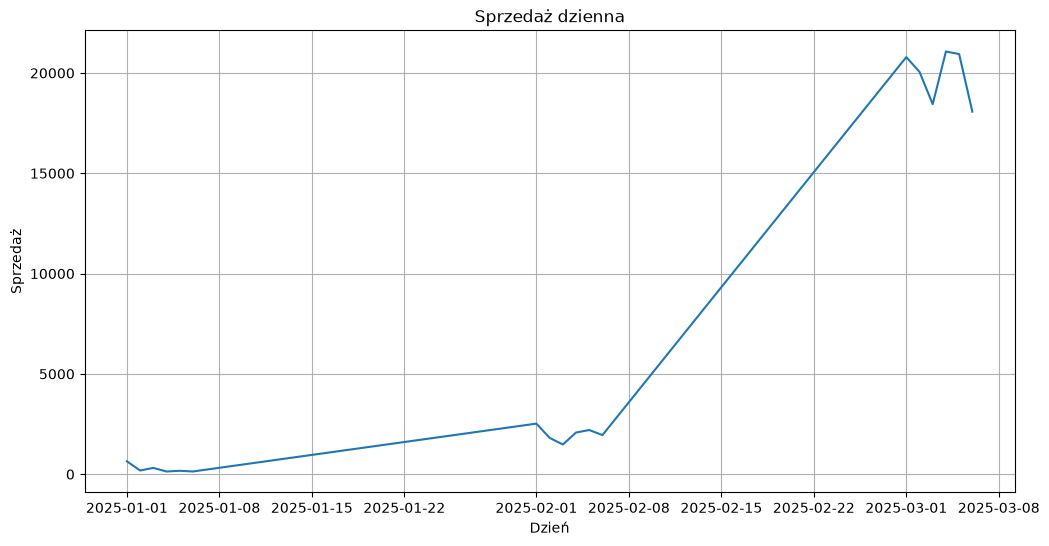

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.lineplot(data=sprzedaz_df, x=sprzedaz_df.index, y='sprzedaz')
plt.title('Sprzedaż dzienna')
plt.xlabel('Dzień')
plt.ylabel('Sprzedaż')
plt.grid(True)
plt.show()


In [18]:
opis_transakcji_df['CenaRazem'] = opis_transakcji_df['Cena'] * opis_transakcji_df['Liczba']

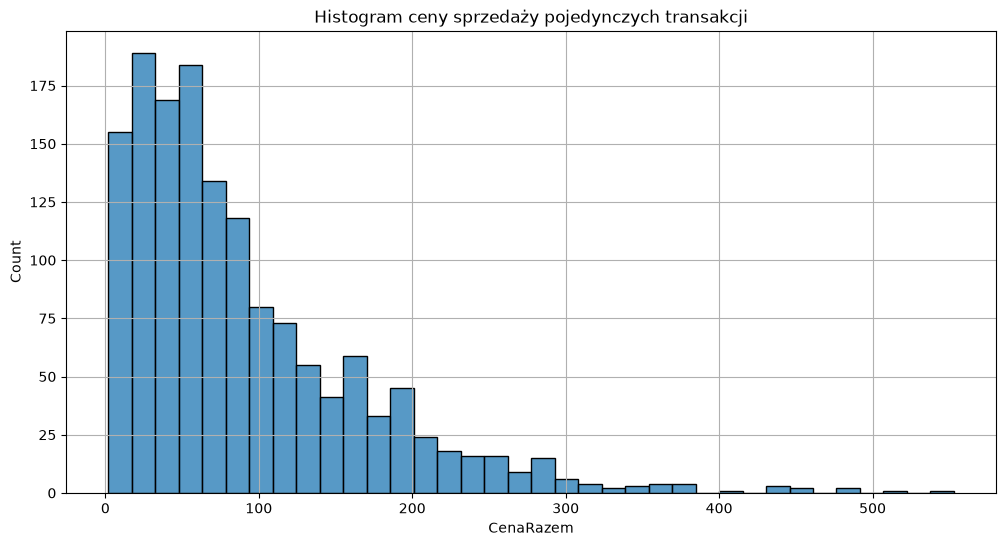

In [19]:
plt.figure(figsize=(12,6))
sns.histplot(data=opis_transakcji_df,x='CenaRazem',bins="auto")
plt.title("Histogram ceny sprzedaży pojedynczych transakcji")
plt.xlabel('CenaRazem')
plt.grid(True)
plt.show()

In [20]:
%%sql
select
    IdSklepu,
    round(sum(ot.Liczba*ot.Cena),2) as CenaRazem
from transakcje t
join opis_transakcji ot
    on t.IdTransakcji = ot.IdTransakcji
group by 1
order by 2
limit 5

 * sqlite:///baza.db
Done.


IdSklepu,CenaRazem
15,1298.68
6,1615.15
27,1700.52
9,1714.95
31,1734.9


In [24]:
engine = create_engine('sqlite:///baza.db')
sprzedaz_na_sklep_df = pd.read_sql(
    """
    select
        IdSklepu,
        round(sum(ot.Liczba*ot.Cena),2) as CenaRazem
    from transakcje t
    join opis_transakcji ot
        on t.IdTransakcji = ot.IdTransakcji
    group by 1
    order by 2
    """,
    con=engine
)


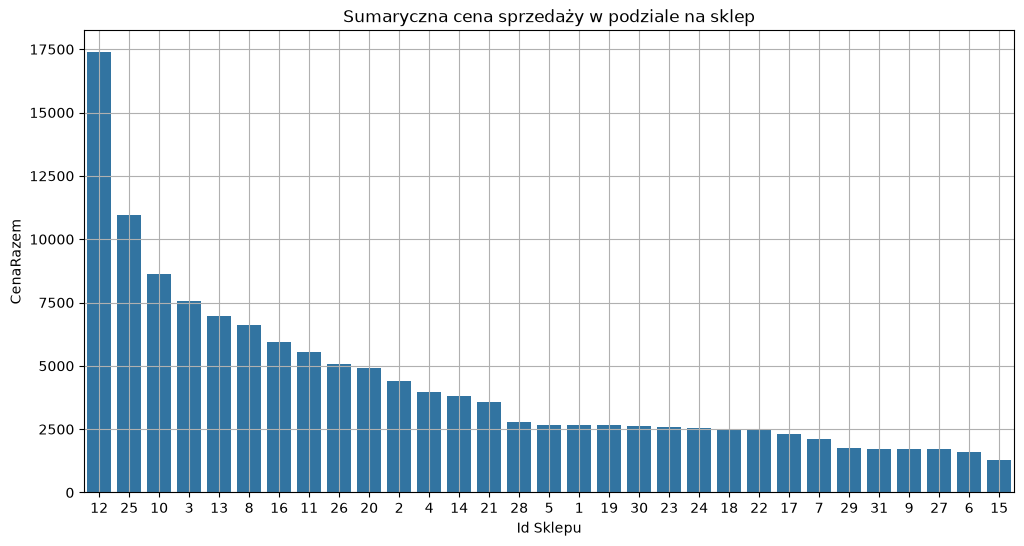

In [25]:
# sortowanie malejąco
sprzedaz_na_sklep_df = sprzedaz_na_sklep_df.sort_values('CenaRazem', ascending=False)

# ustawienie kolejności kategorii
sprzedaz_na_sklep_df['IdSklepu'] = pd.Categorical(
    sprzedaz_na_sklep_df['IdSklepu'],
    categories=sprzedaz_na_sklep_df['IdSklepu'],
    ordered=True
)

plt.figure(figsize=(12,6))
sns.barplot(data=sprzedaz_na_sklep_df,x="IdSklepu",y="CenaRazem")
plt.title("Sumaryczna cena sprzedaży w podziale na sklep")
plt.xlabel('Id Sklepu')
plt.grid(True)
plt.show()

In [26]:
engine = create_engine("sqlite:///baza.db")

sklep_14_df = pd.read_sql(
    """
    select
        case 
            when IdSprzedawcy is NULL then 'kasa'
             else IdSprzedawcy
        end as IdSprzedawcy,
        ot.Liczba,
        ot.Cena,
        round(ot.Liczba*ot.Cena,2) as CenaRazem,
        sum(ot.Liczba*ot.Cena) over (partition by IdSprzedawcy) as sprzedaz
    from transakcje t
    join opis_transakcji ot
        on t.IdTransakcji = ot.IdTransakcji
    where t.IdSklepu = 12
    order by 1, 2
    """,
    engine
)


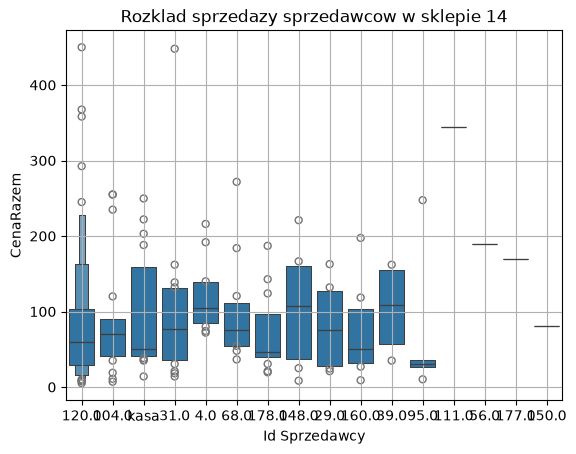

In [27]:
sklep_14_df = sklep_14_df.sort_values('sprzedaz', ascending=False)

sklep_14_df['IdSprzedawcy'] = pd.Categorical(
    sklep_14_df['IdSprzedawcy'],
    categories=sklep_14_df['IdSprzedawcy'].unique().tolist(),
    ordered=True
)



sns.boxenplot(
    data=sklep_14_df,
    x="IdSprzedawcy",
    y="CenaRazem",
    order=sklep_14_df['IdSprzedawcy'].unique().tolist()
)
plt.title("Rozklad sprzedazy sprzedawcow w sklepie 14")
plt.xlabel('Id Sprzedawcy')
plt.grid(True)
plt.show()

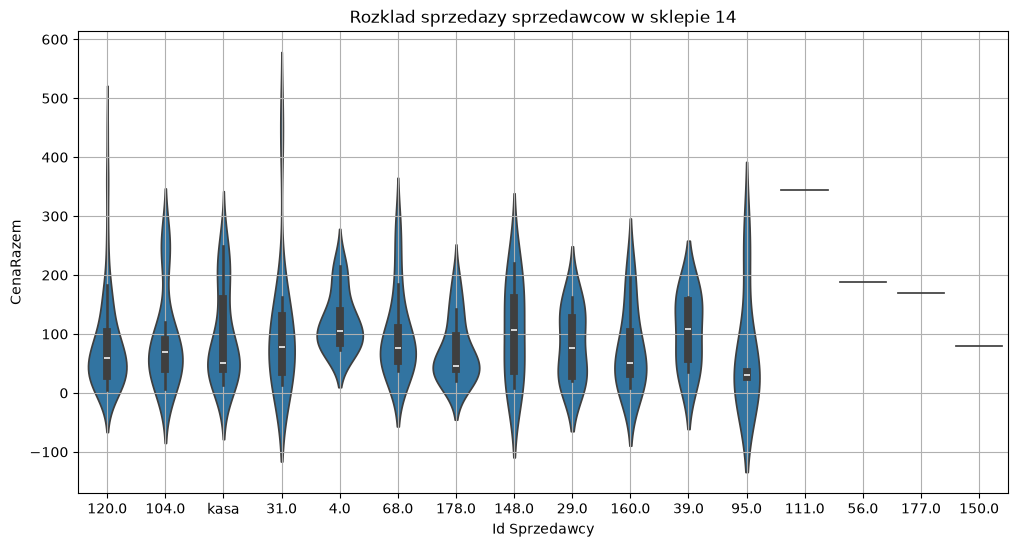

In [28]:
plt.figure(figsize=(12,6))
sns.violinplot(data=sklep_14_df, x="IdSprzedawcy", y="CenaRazem", order=sklep_14_df['IdSprzedawcy'].unique().tolist())
plt.title("Rozklad sprzedazy sprzedawcow w sklepie 14")
plt.xlabel('Id Sprzedawcy')
plt.grid(True)
plt.show()

In [29]:
top10_sklepy_df = pd.read_sql(
    """
    select
        t.IdSklepu,
        sum(ot.Liczba * ot.Cena) as sprzedaz
    from transakcje t
    join opis_transakcji ot
        on t.IdTransakcji = ot.IdTransakcji
    group by t.IdSklepu
    order by sprzedaz desc
    limit 10
    """,
    conn
)
top10_sklepy = top10_sklepy_df["IdSklepu"].tolist()


top10_sprzedawcy_df = pd.read_sql(
    """
    select
        case 
            when t.IdSprzedawcy is NULL then 'kasa'
            else t.IdSprzedawcy
        end as IdSprzedawcy,
        sum(ot.Liczba * ot.Cena) as sprzedaz
    from transakcje t
    join opis_transakcji ot
        on t.IdTransakcji = ot.IdTransakcji
    group by IdSprzedawcy
    order by sprzedaz desc
    limit 10
    """,
    conn
)
top10_sprzedawcy = top10_sprzedawcy_df["IdSprzedawcy"].tolist()


In [30]:
sklepy_sql = ",".join(map(str, top10_sklepy))
sprzedawcy_sql = ",".join(f"'{s}'" for s in top10_sprzedawcy if s != "kasa")

query = f"""
    select
        case 
            when t.IdSprzedawcy is NULL then 'kasa'
            else t.IdSprzedawcy
        end as IdSprzedawcy,
        t.IdSklepu,
        sum(ot.Liczba * ot.Cena) as sprzedaz
    from transakcje t
    join opis_transakcji ot
        on t.IdTransakcji = ot.IdTransakcji
    where t.IdSklepu in ({sklepy_sql})
      and (
            t.IdSprzedawcy in ({sprzedawcy_sql})
            or t.IdSprzedawcy is NULL
          )
    group by IdSprzedawcy, IdSklepu
    order by IdSprzedawcy, IdSklepu
"""

with engine.connect() as conn:
    heatmap_df = pd.read_sql(query, conn)


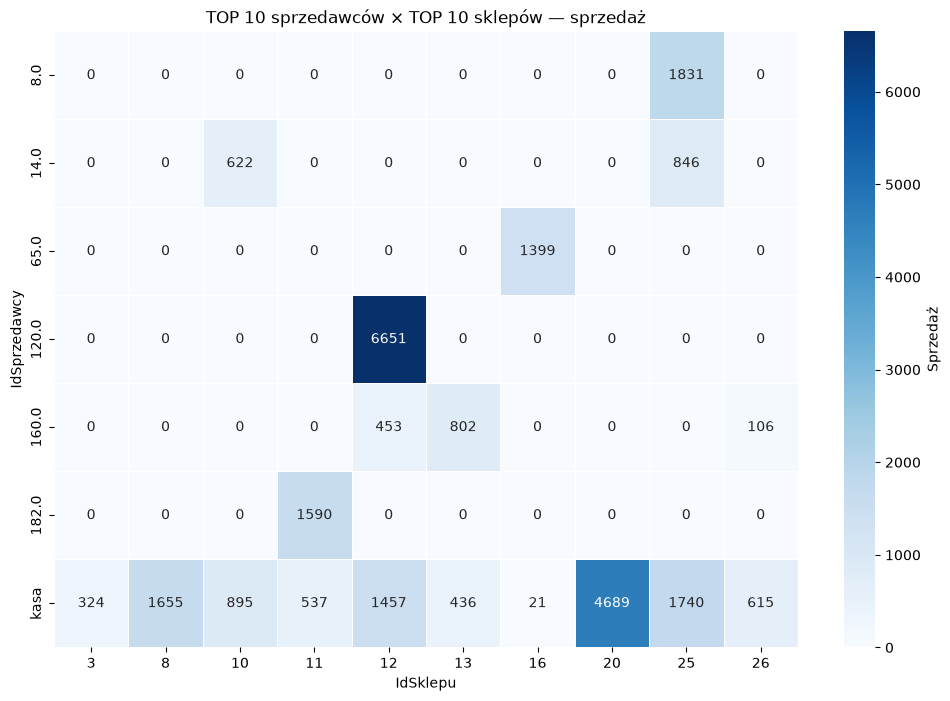

In [31]:
pivot = heatmap_df.pivot_table(
    values="sprzedaz",
    index="IdSprzedawcy",
    columns="IdSklepu",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=.5,
    cbar_kws={"label": "Sprzedaż"}
)
plt.title("TOP 10 sprzedawców × TOP 10 sklepów — sprzedaż")
plt.xlabel("IdSklepu")
plt.ylabel("IdSprzedawcy")
plt.show()


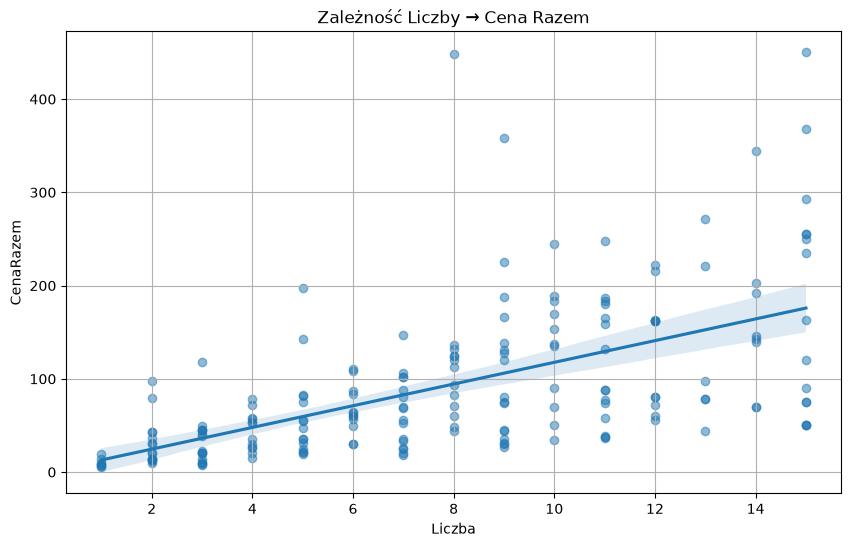

In [32]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=sklep_14_df,
    y="CenaRazem",
    x="Liczba",
    scatter_kws={"alpha":0.5}
)
plt.title("Zależność Liczby → Cena Razem")
plt.grid(True)
plt.show()


# Zapis danych do Excela

In [33]:
import pandas as pd

with pd.ExcelWriter("raport_sprzedaz.xlsx", engine="xlsxwriter") as writer:
    sprzedaz_na_sklep_df.to_excel(writer, sheet_name="Sprzedaz_na_sklep", index=False)
    sprzedaz_df.to_excel(writer, sheet_name="Sprzedaz_dzienna", index=True)


# Odczyt danyh z Excela

In [34]:

sprzedaz_dzienna_df = pd.read_excel("raport_sprzedaz.xlsx", sheet_name="Sprzedaz_dzienna")
sprzedaz_dzienna_df.head()


,dzien,sprzedaz
0,2025-01-01,645.34
1,2025-01-02,184.80
2,2025-01-03,315.00
3,2025-01-04,136.00
4,2025-01-05,171.00


In [35]:
import pandas as pd

wszystkie = pd.read_excel("raport_sprzedaz.xlsx", sheet_name=None)


In [36]:
wszystkie

{'Sprzedaz_na_sklep':     IdSklepu  CenaRazem
 0         12   17370.92
 1         25   10948.67
 2         10    8629.86
 3          3    7557.50
 4         13    6963.54
 5          8    6623.75
 6         16    5940.44
 7         11    5565.70
 8         26    5065.24
 9         20    4907.26
 10         2    4390.28
 11         4    3953.31
 12        14    3828.75
 13        21    3575.95
 14        28    2763.90
 15         5    2671.09
 16         1    2655.12
 17        19    2652.50
 18        30    2622.33
 19        23    2582.82
 20        24    2537.45
 21        18    2499.60
 22        22    2467.29
 23        17    2289.90
 24         7    2123.35
 25        29    1764.65
 26        31    1734.90
 27         9    1714.95
 28        27    1700.52
 29         6    1615.15
 30        15    1298.68,
 'Sprzedaz_dzienna':         dzien    sprzedaz
 0  2025-01-01    645.3400
 1  2025-01-02    184.8000
 2  2025-01-03    315.0000
 3  2025-01-04    136.0000
 4  2025-01-05    171.0

In [ ]:
wszystkie['Sprzedaz_na_sklep'].describe()